# Task_2 Customer Segmentation

## Objective
The objective of this task is to segment customers based on their annual income and spending behavior using unsupervised learning (K-Means Clustering) and propose marketing strategies for each segment.

### Import Libraries

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('Mall_Customers.csv')

In [4]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.shape

(200, 5)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [7]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

We have no missing or null values in our dataset

In [9]:
df.describe()  # For Statistical Analysis of Dataset

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


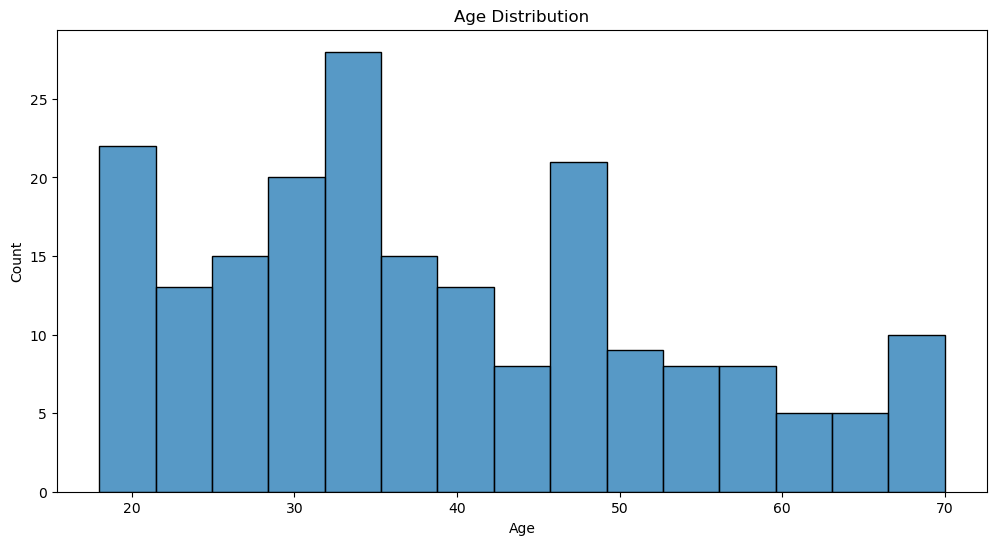

In [19]:
plt.figure(figsize=(12,6))
sns.histplot(df['Age'], bins=15)
plt.title("Age Distribution")
plt.show()

Most customers are concentrated in the young to middle-age range, with fewer customers at very high ages

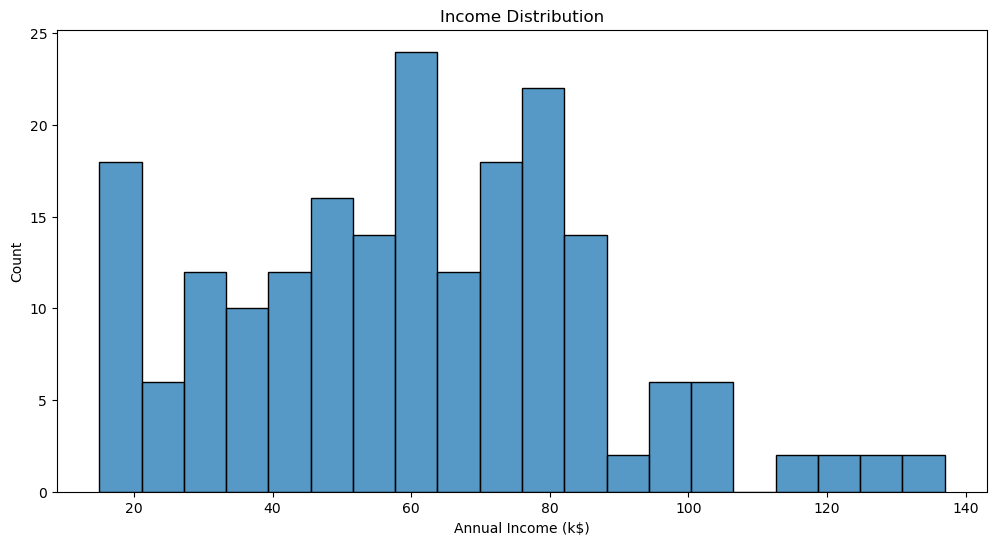

In [23]:
plt.figure(figsize=(12,6))
sns.histplot(df['Annual Income (k$)'], bins=20)
plt.title("Income Distribution")
plt.show()

Customer incomes are spread across different income levels, with a higher concentration in the middle-income range.

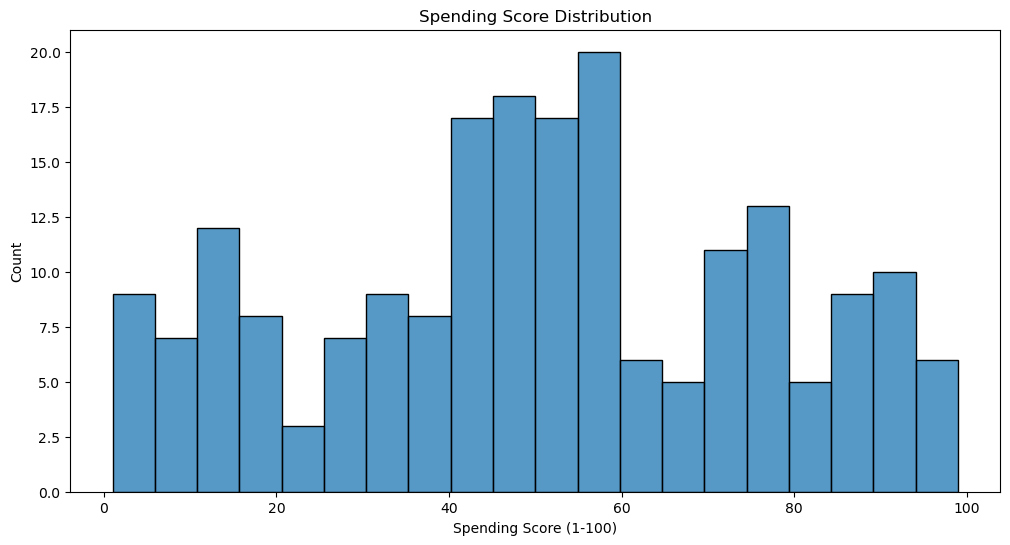

In [24]:
plt.figure(figsize=(12,6))
sns.histplot(df['Spending Score (1-100)'], bins=20)
plt.title("Spending Score Distribution")
plt.show()

Customer incomes are spread across different income levels, with a higher concentration in the middle-income range.

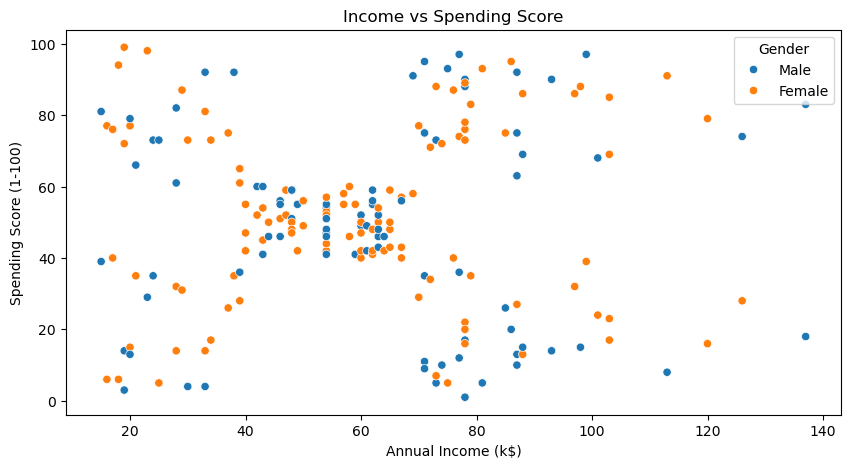

In [31]:
plt.figure(figsize=(10,5))

sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Gender')
plt.title("Income vs Spending Score")
plt.show()

The scatter plot does not show clearly separated clusters visually, but K-Means can still identify hidden patterns based on distance between data points.

In [34]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++',random_state=42 )
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

Tests different values of K (number of clusters) and calculates WCSS (inertia) for each to find the optimal number of customer segments using the Elbow Method.

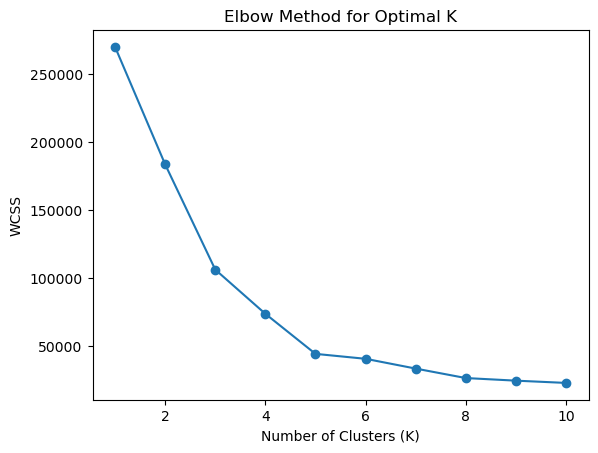

In [36]:
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal K')
plt.savefig('age_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [37]:
kmeans = KMeans(    n_clusters=5,init='k-means++', random_state=42)
clusters = kmeans.fit_predict(X)

In [38]:
df['Cluster'] = clusters

In [40]:
df['Cluster'].value_counts()

Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64

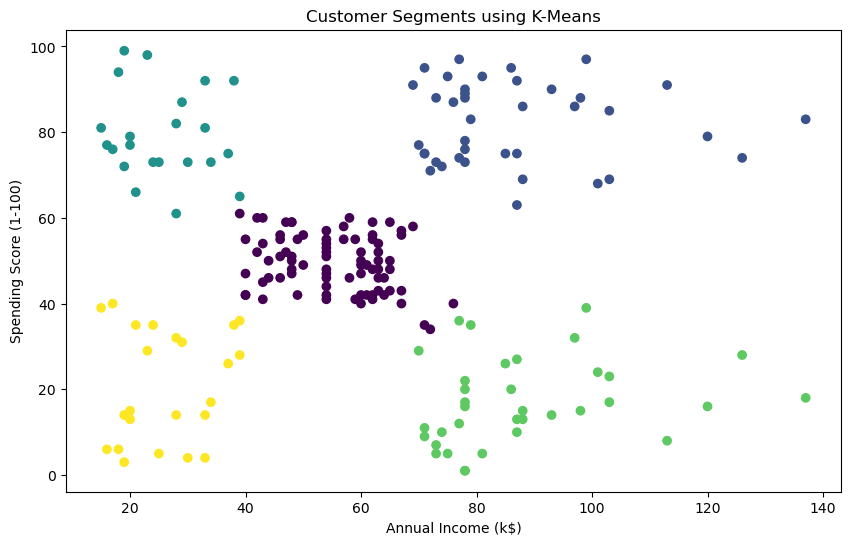

In [42]:
plt.figure(figsize=(10,6))
plt.scatter(X['Annual Income (k$)'],X['Spending Score (1-100)'],c=clusters)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments using K-Means')

plt.show()

K-Means clustering was applied with K = 5 to segment customers into five distinct groups based on annual income and spending score.

In [43]:
df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


The K-Means algorithm successfully segmented customers into five distinct groups based on income and spending behavior. Each cluster represents a unique customer profile ranging from high-value VIP customers to low-engagement customers, allowing targeted marketing strategies for each segment.

In [44]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

In [45]:
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = clusters

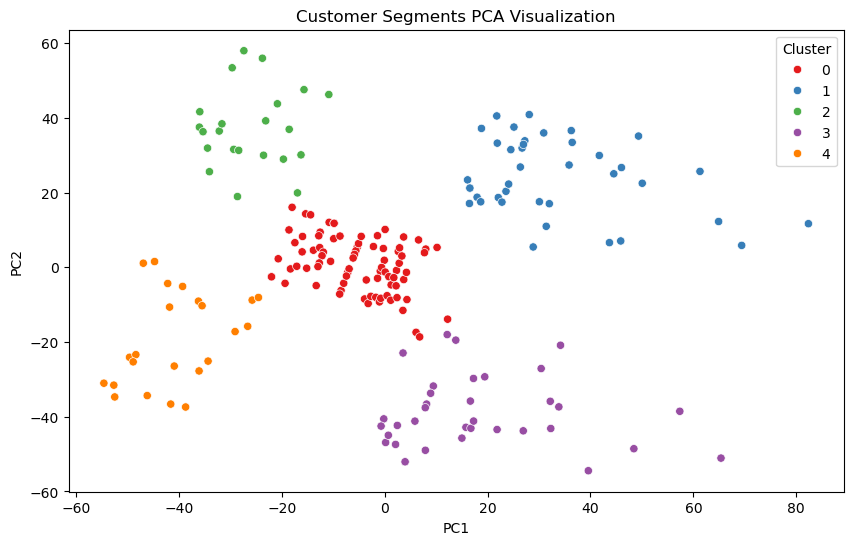

In [47]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='PC1',y='PC2',hue='Cluster',data=df_pca,palette='Set1')
plt.title('Customer Segments PCA Visualization')
plt.show()

PCA was applied to reduce the dimensionality of the dataset and visualize customer clusters in a 2D space. It helps in understanding cluster separation more clearly.

## Conclusion
K-Means clustering successfully segmented customers into five meaningful groups based on their purchasing behavior. These segments provide valuable insights for targeted marketing strategies, enabling businesses to improve customer engagement, retention, and revenue optimization.

# Marketing Strategies for Customer Segments

## Cluster 0 – Average Customers

**Characteristics:**

* Medium annual income
* Medium spending score

**Marketing Strategy:**

* Offer seasonal promotions and discounts.
* Recommend popular products through email campaigns.
* Encourage repeat purchases through loyalty programs.

## Cluster 1 – VIP Customers

**Characteristics:**

* High annual income
* High spending score

**Marketing Strategy:**

* Provide exclusive VIP memberships and premium services.
* Offer early access to new products and special events.
* Reward loyal customers with personalized offers.

## Cluster 2 – Low Income, High Spenders

**Characteristics:**

* Low annual income
* High spending score

**Marketing Strategy:**

* Offer discounts, coupons, and bundle deals.
* Promote affordable products with high value.
* Use targeted promotions to maintain customer engagement.

## Cluster 3 – High Income, Low Spenders

**Characteristics:**

* High annual income
* Low spending score

**Marketing Strategy:**

* Use personalized marketing campaigns to increase spending.
* Highlight premium products and exclusive benefits.
* Offer limited-time discounts and special incentives.

## Cluster 4 – Low Income, Low Spenders

**Characteristics:**

* Low annual income
* Low spending score

**Marketing Strategy:**

* Focus on budget-friendly products and promotions.
* Use mass marketing campaigns to reach this segment efficiently.
* Minimize marketing costs while maintaining engagement.

# Conclusion

K-Means clustering successfully segmented customers into five distinct groups based on annual income and spending behavior. These customer segments can help businesses design targeted marketing strategies, improve customer satisfaction, and increase overall revenue.
